## Ансамбли и полносвязные нейронные сети
В этом ноутбуке вам нужно обучить модели на датасете классификации из предыдущего ноутбука и сравнить результаты. Вам будет предоставлен baseline, на основе которого вы будете доделывать предсказывающие модели. Оценка лабы будет зависеть от ROC-AUC на тестовых данных по следующим критериям:
\
AUC - на тестовых данных
- $AUC \leq 0.76$ - 0 баллов
- $0.76 < AUC \leq 0.77$ - 2 балла
- $0.77 < AUC \leq 0.78$ - 4 балла
- $0.78 < AUC \leq 0.79$ - 6 баллов
- $0.79 < AUC \leq 0.80$ - 8 баллов
- $AUC > 0.80$ - 10 баллов


In [43]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import roc_auc_score, precision_score, recall_score, roc_curve, accuracy_score

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import mutual_info_classif

import warnings
from sklearn.exceptions import ConvergenceWarning

In [2]:
data = pd.read_csv('german.csv', sep=';')
print(data.head())

X = data.iloc[:, 1:].to_numpy()
y = data.iloc[:, 0].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

   Creditability  Account_Balance  Duration_of_Credit_monthly  \
0              1                1                          18   
1              1                1                           9   
2              1                2                          12   
3              1                1                          12   
4              1                1                          12   

   Payment_Status_of_Previous_Credit  Purpose  Credit_Amount  \
0                                  4        2           1049   
1                                  4        0           2799   
2                                  2        9            841   
3                                  4        0           2122   
4                                  4        0           2171   

   Value_Savings_Stocks  Length_of_current_employment  Instalment_per_cent  \
0                     1                             2                    4   
1                     1                             3               

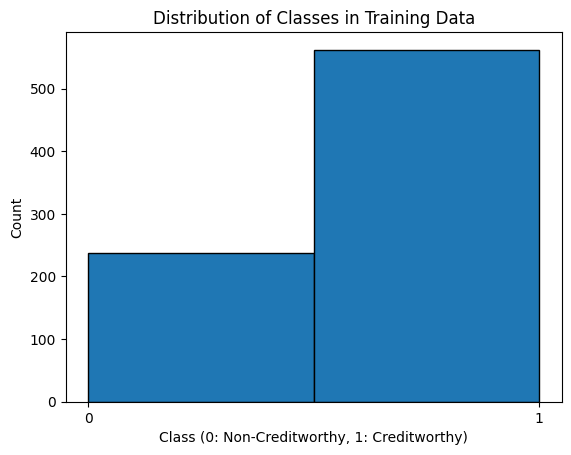

In [3]:
plt.hist(y_train, bins=2, edgecolor='k')
plt.xticks([0, 1])
plt.xlabel('Class (0: Non-Creditworthy, 1: Creditworthy)')
plt.ylabel('Count')
plt.title('Distribution of Classes in Training Data')
plt.show()

In [4]:
# Обучение Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Прогноз на тестовых данных
rf_pred = rf_model.predict(X_test)

# Расчет метрик для Random Forest
rf_roc_auc = roc_auc_score(y_test, rf_pred)
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)

print("Random Forest метрики:")
print(f"ROC AUC: {rf_roc_auc:.2f}")
print(f"Accuracy: {rf_accuracy:.2f}")
print(f"Precision: {rf_precision:.2f}")
print(f"Recall: {rf_recall:.2f}")

# Обучение Gradient Boosting
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)

# Прогноз на тестовых данных
gb_pred = gb_model.predict(X_test)

# Расчет метрик для Gradient Boosting
gb_roc_auc = roc_auc_score(y_test, gb_pred)
gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)

print("\nGradient Boosting метрики:")
print(f"ROC AUC: {gb_roc_auc:.2f}")
print(f"Accuracy: {gb_accuracy:.2f}")
print(f"Precision: {gb_precision:.2f}")
print(f"Recall: {gb_recall:.2f}")

Random Forest метрики:
ROC AUC: 0.68
Accuracy: 0.76
Precision: 0.78
Recall: 0.90

Gradient Boosting метрики:
ROC AUC: 0.67
Accuracy: 0.73
Precision: 0.79
Recall: 0.84


In [5]:
# Обучение MLP (Multi-Layer Perceptron) нейронной сети
mlp_model = MLPClassifier(hidden_layer_sizes=(30,), max_iter=500, random_state=42)
mlp_model.fit(X_train, y_train)

# Прогноз на тестовых данных
mlp_pred = mlp_model.predict(X_test)

# Расчет метрик для MLP нейронной сети
mlp_roc_auc = roc_auc_score(y_test, mlp_pred)
mlp_accuracy = accuracy_score(y_test, mlp_pred)
mlp_precision = precision_score(y_test, mlp_pred)
mlp_recall = recall_score(y_test, mlp_pred)

print("\nMLP (Neural Network) метрики:")
print(f"ROC AUC: {mlp_roc_auc:.2f}")
print(f"Accuracy: {mlp_accuracy:.2f}")
print(f"Precision: {mlp_precision:.2f}")
print(f"Recall: {mlp_recall:.2f}")


MLP (Neural Network) метрики:
ROC AUC: 0.56
Accuracy: 0.65
Precision: 0.72
Recall: 0.79


## Экспериментируйте
Для получения лучшего качества придется поэкспериментировать. Подсказка: попробуйте оптимизировать гиперпараметры модели

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

mlp_params = {
    'hidden_layer_sizes': [(25,), (40,), (50,), (60,)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.001, 0.002],
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [300, 400, 500, 600]
}

# Retain default multiprocessing backend for optimal CPU utilization
mlp_grid = GridSearchCV(
    MLPClassifier(random_state=42), 
    mlp_params, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=0
)
mlp_grid.fit(X_train_scaled, y_train)

print(f"\nBest MLP parameters: {mlp_grid.best_params_}")
print(f"Best CV ROC AUC: {mlp_grid.best_score_:.4f}")

mlp_best = mlp_grid.best_estimator_
mlp_pred_proba = mlp_best.predict_proba(X_test_scaled)[:, 1]

mlp_roc_auc_tuned = roc_auc_score(y_test, mlp_pred_proba)
mlp_accuracy_tuned = accuracy_score(y_test, mlp_best.predict(X_test_scaled))
mlp_precision_tuned = precision_score(y_test, mlp_best.predict(X_test_scaled))
mlp_recall_tuned = recall_score(y_test, mlp_best.predict(X_test_scaled))

print(f"\nTuned MLP Test Metrics:")
print(f"ROC AUC:   {mlp_roc_auc_tuned:.4f}")
print(f"Accuracy:  {mlp_accuracy_tuned:.4f}")
print(f"Precision: {mlp_precision_tuned:.4f}")
print(f"Recall:    {mlp_recall_tuned:.4f}")


Best MLP parameters: {'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (50,), 'learning_rate': 'constant', 'max_iter': 300}
Best CV ROC AUC: 0.7848

Tuned MLP Test Metrics:
ROC AUC:   0.7908
Accuracy:  0.7700
Precision: 0.8194
Recall:    0.8551


In [9]:
gb_params = {
    'n_estimators': [75, 100, 125 ],
    'learning_rate': [0.05, 0.075, 0.1, 0.125],
    'max_depth': [7, 9, 11, 13],
    'min_samples_split': [2, 3],
    'min_samples_leaf': [1, 2],
    'subsample': [0.8, 0.9, 1.0]
}

gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, cv=5, scoring='roc_auc', n_jobs=-1)
gb_grid.fit(X_train, y_train)

print(f"\nBest Gradient Boosting parameters: {gb_grid.best_params_}")
print(f"Best CV ROC AUC: {gb_grid.best_score_:.4f}")

gb_best = gb_grid.best_estimator_
gb_pred_proba = gb_best.predict_proba(X_test)[:, 1]
gb_roc_auc_tuned = roc_auc_score(y_test, gb_pred_proba)
gb_accuracy_tuned = accuracy_score(y_test, gb_best.predict(X_test))
gb_precision_tuned = precision_score(y_test, gb_best.predict(X_test))
gb_recall_tuned = recall_score(y_test, gb_best.predict(X_test))

print(f"\nTuned Gradient Boosting Test Metrics:")
print(f"ROC AUC:   {gb_roc_auc_tuned:.4f}")
print(f"Accuracy:  {gb_accuracy_tuned:.4f}")
print(f"Precision: {gb_precision_tuned:.4f}")
print(f"Recall:    {gb_recall_tuned:.4f}")


Best Gradient Boosting parameters: {'learning_rate': 0.1, 'max_depth': 13, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 125, 'subsample': 0.9}
Best CV ROC AUC: 0.8027

Tuned Gradient Boosting Test Metrics:
ROC AUC:   0.7532
Accuracy:  0.7700
Precision: 0.8194
Recall:    0.8551


In [10]:
rf_params = {
    'n_estimators': [200, 250, 275, 300, 325, 350],
    'max_depth': [10, 12, 13, 15, 17, 18, 20],
    'min_samples_split': [1, 2, 3, 4],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)

print(f"\nBest Random Forest parameters: {rf_grid.best_params_}")
print(f"Best CV ROC AUC: {rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_
rf_pred_proba = rf_best.predict_proba(X_test)[:, 1]
rf_roc_auc_tuned = roc_auc_score(y_test, rf_pred_proba)
rf_accuracy_tuned = accuracy_score(y_test, rf_best.predict(X_test))
rf_precision_tuned = precision_score(y_test, rf_best.predict(X_test))
rf_recall_tuned = recall_score(y_test, rf_best.predict(X_test))

print(f"\nTuned Random Forest Test Metrics:")
print(f"ROC AUC:   {rf_roc_auc_tuned:.4f}")
print(f"Accuracy:  {rf_accuracy_tuned:.4f}")
print(f"Precision: {rf_precision_tuned:.4f}")
print(f"Recall:    {rf_recall_tuned:.4f}")

C:\Users\Administrator\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
840 fits failed out of a total of 3360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
840 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Administrator\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Administrator\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\A


Best Random Forest parameters: {'max_depth': 13, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV ROC AUC: 0.7966

Tuned Random Forest Test Metrics:
ROC AUC:   0.7798
Accuracy:  0.7500
Precision: 0.7821
Recall:    0.8841


In [11]:
rf_params = {
    'n_estimators': [275, 287, 300, 312, 325],
    'max_depth': [10, 12, 13, 14, 15],
    'min_samples_split': [1, 2],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_grid1 = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='roc_auc', n_jobs=-1)
rf_grid1.fit(X_train, y_train)

print(f"\nBest Random Forest parameters: {rf_grid1.best_params_}")
print(f"Best CV ROC AUC: {rf_grid1.best_score_:.4f}")

rf_best1 = rf_grid1.best_estimator_
rf_pred_proba1 = rf_best1.predict_proba(X_test)[:, 1]
rf_roc_auc_tuned1 = roc_auc_score(y_test, rf_pred_proba1)
rf_accuracy_tuned1 = accuracy_score(y_test, rf_best1.predict(X_test))
rf_precision_tuned1 = precision_score(y_test, rf_best1.predict(X_test))
rf_recall_tuned1 = recall_score(y_test, rf_best1.predict(X_test))

print(f"\nTuned Random Forest Test Metrics:")
print(f"ROC AUC:   {rf_roc_auc_tuned1:.4f}")
print(f"Accuracy:  {rf_accuracy_tuned1:.4f}")
print(f"Precision: {rf_precision_tuned1:.4f}")
print(f"Recall:    {rf_recall_tuned1:.4f}")

C:\Users\Administrator\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
500 fits failed out of a total of 1000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
500 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Administrator\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Administrator\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\A


Best Random Forest parameters: {'max_depth': 14, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 325}
Best CV ROC AUC: 0.7972

Tuned Random Forest Test Metrics:
ROC AUC:   0.7863
Accuracy:  0.7400
Precision: 0.7792
Recall:    0.8696


# Зафиксируем без работы с признаками:  
- Random Forest ROC AUC:   0.7863
- Gradient Boosting ROC AUC:   0.7653
- MLP Test ROC AUC:   0.7908


# Feature Engineering

информацию о датасете взял с контеста https://www.kaggle.com/datasets/mpwolke/cusersmarildownloadsgermancsv

In [17]:
df = pd.read_csv('german.csv', sep=';')
df = df.drop(columns=['Foreign_Worker'], errors='ignore') # в инфомрации о датасете: ForeignWorker variable may be dropped from the study
print(df.head())

   Creditability  Account_Balance  Duration_of_Credit_monthly  \
0              1                1                          18   
1              1                1                           9   
2              1                2                          12   
3              1                1                          12   
4              1                1                          12   

   Payment_Status_of_Previous_Credit  Purpose  Credit_Amount  \
0                                  4        2           1049   
1                                  4        0           2799   
2                                  2        9            841   
3                                  4        0           2122   
4                                  4        0           2171   

   Value_Savings_Stocks  Length_of_current_employment  Instalment_per_cent  \
0                     1                             2                    4   
1                     1                             3               

In [18]:
df.shape

(1000, 20)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Creditability                      1000 non-null   int64
 1   Account_Balance                    1000 non-null   int64
 2   Duration_of_Credit_monthly         1000 non-null   int64
 3   Payment_Status_of_Previous_Credit  1000 non-null   int64
 4   Purpose                            1000 non-null   int64
 5   Credit_Amount                      1000 non-null   int64
 6   Value_Savings_Stocks               1000 non-null   int64
 7   Length_of_current_employment       1000 non-null   int64
 8   Instalment_per_cent                1000 non-null   int64
 9   Sex_Marital_Status                 1000 non-null   int64
 10  Guarantors                         1000 non-null   int64
 11  Duration_in_Current_address        1000 non-null   int64
 12  Most_valuable_available_asset   

Использую one-hot encoding для категорий (Purpose, Sex_Marital_Status, Guarantors, Concurrent_Credits, Type_of_apartment, Most_valuable_available_asset, Telephone)

In [20]:
nominal_features = [
    'Purpose', 'Sex_Marital_Status', 'Guarantors', 
    'Concurrent_Credits', 'Type_of_apartment', 
    'Most_valuable_available_asset', 'Telephone'
]

df_encoded = pd.get_dummies(df, columns=nominal_features, drop_first=True, dtype=int)

In [23]:
df_encoded['Monthly'] = df_encoded['Credit_Amount'] / (df_encoded['Duration_of_Credit_monthly'] + 1) # нагрузка в месяц
df_encoded['Has_Payment_Issues'] = (df_encoded['Payment_Status_of_Previous_Credit'] == 1).astype(int)


In [31]:
df_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 37 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Creditability                      1000 non-null   int64  
 1   Account_Balance                    1000 non-null   int64  
 2   Duration_of_Credit_monthly         1000 non-null   int64  
 3   Payment_Status_of_Previous_Credit  1000 non-null   int64  
 4   Credit_Amount                      1000 non-null   int64  
 5   Value_Savings_Stocks               1000 non-null   int64  
 6   Length_of_current_employment       1000 non-null   int64  
 7   Instalment_per_cent                1000 non-null   int64  
 8   Duration_in_Current_address        1000 non-null   int64  
 9   Age_years                          1000 non-null   int64  
 10  No_of_Credits_at_this_Bank         1000 non-null   int64  
 11  Occupation                         1000 non-null   int64  
 12  No_o

In [39]:
y = df_encoded['Creditability']

X = df_encoded.drop(columns=['Creditability'])

numeric_features = [
    'Account_Balance', 'Duration_of_Credit_monthly', 'Payment_Status_of_Previous_Credit',
    'Credit_Amount', 'Value_Savings_Stocks', 'Length_of_current_employment',
    'Instalment_per_cent', 'Duration_in_Current_address', 'Age_years',
    'No_of_Credits_at_this_Bank', 'Occupation', 'No_of_dependents',
    'Monthly', 'Has_Payment_Issues'
]

# Бинарные признаки (результат One-Hot Encoding)
binary_features = [col for col in X.columns if col not in numeric_features]

print(f"Всего признаков: {X.shape[1]}")
print(f"Числовые/порядковые: {len(numeric_features)}")
print(f"Бинарные: {len(binary_features)}")

Всего признаков: 36
Числовые/порядковые: 14
Бинарные: 22


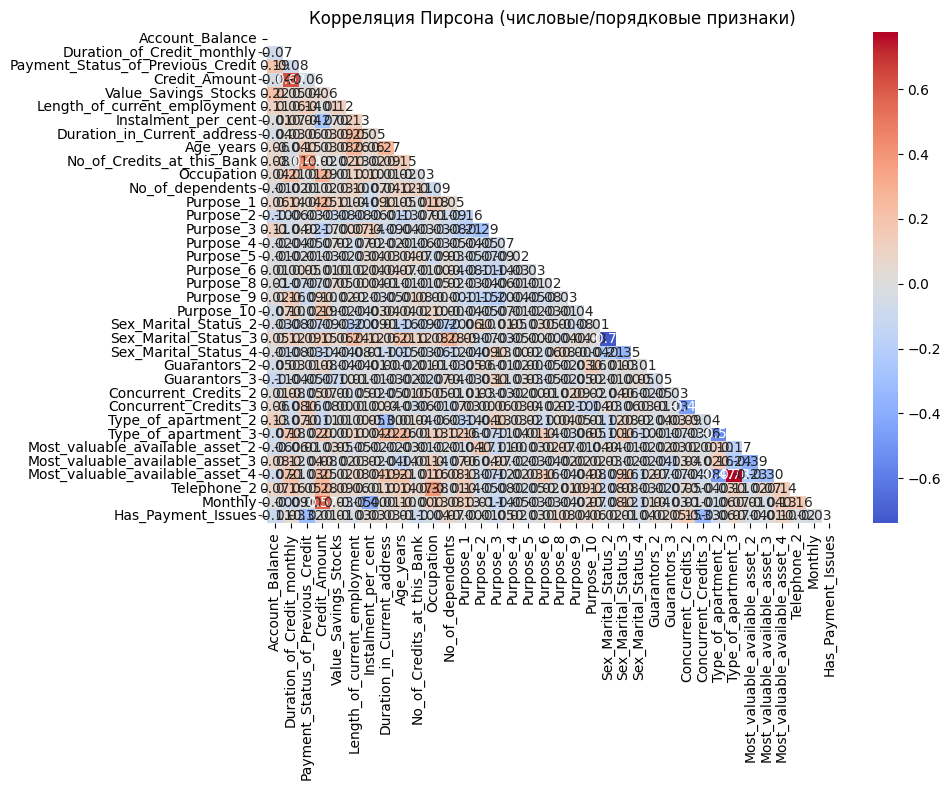

корреляция > 0.7:
  Sex_Marital_Status_2 ↔ Sex_Marital_Status_3: -0.738
  Type_of_apartment_3 ↔ Most_valuable_available_asset_4: 0.775


In [40]:
numeric_existing = [c for c in numeric_features if c in X.columns]

corr_num = X.corr(method='pearson')

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_num, dtype=bool))
sns.heatmap(corr_num, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляция Пирсона (числовые/порядковые признаки)')
plt.tight_layout()
plt.show()

# Вывод сильных корреляций (> 0.7)
print("корреляция > 0.7:")
found = False
for i in range(len(corr_num.columns)):
    for j in range(i+1, len(corr_num.columns)):
        val = corr_num.iloc[i, j]
        if abs(val) > 0.7:
            print(f"  {corr_num.columns[i]} ↔ {corr_num.columns[j]}: {val:.3f}")
            found = True

In [48]:
y = df_encoded['Creditability']
X = df_encoded.drop(columns=['Creditability'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_15708\617107934.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mi_score', y='feature', data=mi_df.head(20), palette='viridis')


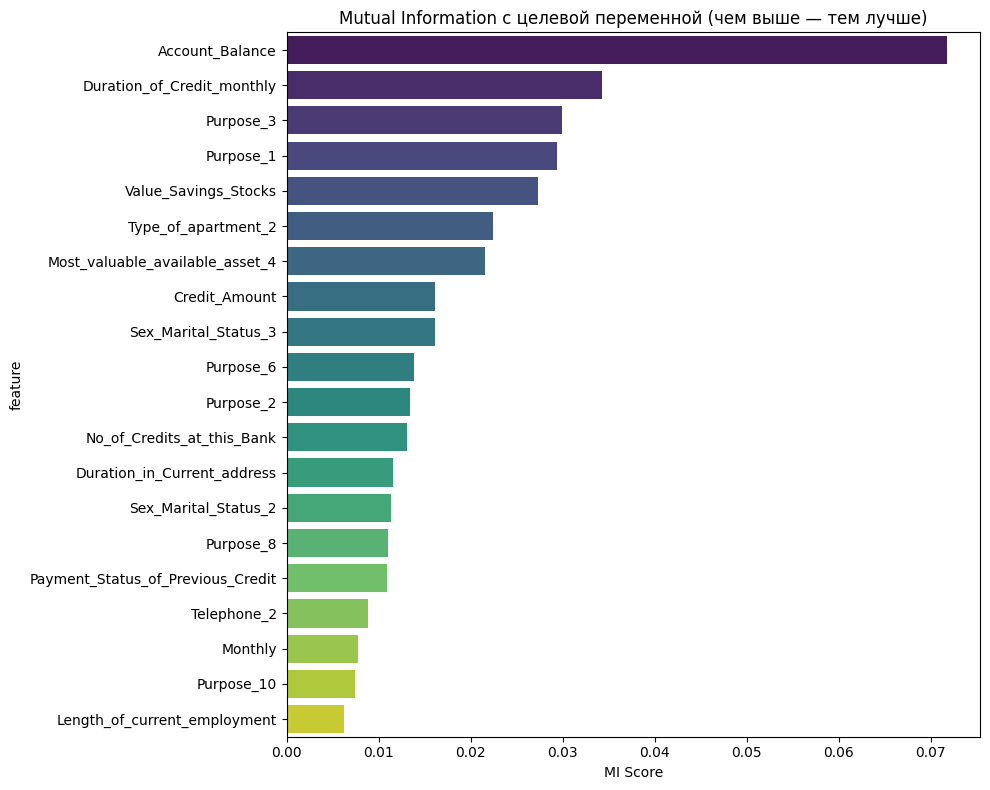


Топ-15 признаков по важности (Mutual Information):
  Account_Balance                          числовой   MI=0.0718
  Duration_of_Credit_monthly               числовой   MI=0.0343
  Purpose_3                                бинарный   MI=0.0300
  Purpose_1                                бинарный   MI=0.0294
  Value_Savings_Stocks                     числовой   MI=0.0274
  Type_of_apartment_2                      бинарный   MI=0.0225
  Most_valuable_available_asset_4          бинарный   MI=0.0215
  Credit_Amount                            числовой   MI=0.0161
  Sex_Marital_Status_3                     бинарный   MI=0.0161
  Purpose_6                                бинарный   MI=0.0139
  Purpose_2                                бинарный   MI=0.0135
  No_of_Credits_at_this_Bank               числовой   MI=0.0131
  Duration_in_Current_address              числовой   MI=0.0116
  Sex_Marital_Status_2                     бинарный   MI=0.0114
  Purpose_8                                бинарный 

In [49]:
# Вычисляем Mutual Information для всех признаков
mi_scores = mutual_info_classif(X, y, random_state=42, discrete_features='auto')

# Создаём таблицу результатов
mi_df = pd.DataFrame({
    'feature': X.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

# Визуализация топ-20
plt.figure(figsize=(10, 8))
sns.barplot(x='mi_score', y='feature', data=mi_df.head(20), palette='viridis')
plt.title('Mutual Information с целевой переменной (чем выше — тем лучше)')
plt.xlabel('MI Score')
plt.tight_layout()
plt.show()

print("\nТоп-15 признаков по важности (Mutual Information):")
for i, row in mi_df.head(15).iterrows():
    ftype = "бинарный" if row['feature'] in binary_features else "числовой"
    print(f"  {row['feature']:<40} {ftype:<10} MI={row['mi_score']:.4f}")

zero_mi = mi_df[mi_df['mi_score'] < 0.001]['feature'].tolist()
if zero_mi:
    print(f"\nПризнаки с почти нулевой важностью ({len(zero_mi)} шт.):")
    print(f"  {zero_mi[:10]}{'...' if len(zero_mi) > 10 else ''}")

In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [50]:
rf_params = {
    'n_estimators': [275, 287, 300, 312, 325],
    'max_depth': [10, 12, 13, 14, 15],
    'min_samples_split': [1, 2],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_grid1 = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=5, scoring='roc_auc', n_jobs=-1)
rf_grid1.fit(X_train, y_train)

print(f"\nBest Random Forest parameters: {rf_grid1.best_params_}")
print(f"Best CV ROC AUC: {rf_grid1.best_score_:.4f}")

rf_best1 = rf_grid1.best_estimator_
rf_pred_proba1 = rf_best1.predict_proba(X_test)[:, 1]
rf_roc_auc_tuned1 = roc_auc_score(y_test, rf_pred_proba1)
rf_accuracy_tuned1 = accuracy_score(y_test, rf_best1.predict(X_test))
rf_precision_tuned1 = precision_score(y_test, rf_best1.predict(X_test))
rf_recall_tuned1 = recall_score(y_test, rf_best1.predict(X_test))

print(f"\nTuned Random Forest Test Metrics:")
print(f"ROC AUC:   {rf_roc_auc_tuned1:.4f}")
print(f"Accuracy:  {rf_accuracy_tuned1:.4f}")
print(f"Precision: {rf_precision_tuned1:.4f}")
print(f"Recall:    {rf_recall_tuned1:.4f}")

C:\Users\Administrator\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
500 fits failed out of a total of 1000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
500 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Administrator\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Administrator\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "C:\Users\A


Best Random Forest parameters: {'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 325}
Best CV ROC AUC: 0.7934

Tuned Random Forest Test Metrics:
ROC AUC:   0.8227
Accuracy:  0.7800
Precision: 0.7824
Recall:    0.9500


In [57]:
gb_params = {
    'n_estimators': [50, 75],
    'learning_rate': [0.1, 0.125, 0.15],
    'max_depth': [10, 11, 12],
    'min_samples_split': [3, 4],
    'min_samples_leaf': [1, 2],
    'subsample': [0.75,  0.8, 0.85]
}

gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), gb_params, cv=5, scoring='roc_auc', n_jobs=-1)
gb_grid.fit(X_train, y_train)

print(f"\nBest Gradient Boosting parameters: {gb_grid.best_params_}")
print(f"Best CV ROC AUC: {gb_grid.best_score_:.4f}")

gb_best = gb_grid.best_estimator_
gb_pred_proba = gb_best.predict_proba(X_test)[:, 1]
gb_roc_auc_tuned = roc_auc_score(y_test, gb_pred_proba)
gb_accuracy_tuned = accuracy_score(y_test, gb_best.predict(X_test))
gb_precision_tuned = precision_score(y_test, gb_best.predict(X_test))
gb_recall_tuned = recall_score(y_test, gb_best.predict(X_test))

print(f"\nTuned Gradient Boosting Test Metrics:")
print(f"ROC AUC:   {gb_roc_auc_tuned:.4f}")
print(f"Accuracy:  {gb_accuracy_tuned:.4f}")
print(f"Precision: {gb_precision_tuned:.4f}")
print(f"Recall:    {gb_recall_tuned:.4f}")


Best Gradient Boosting parameters: {'learning_rate': 0.15, 'max_depth': 11, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 75, 'subsample': 0.85}
Best CV ROC AUC: 0.7862

Tuned Gradient Boosting Test Metrics:
ROC AUC:   0.8007
Accuracy:  0.7750
Precision: 0.7914
Recall:    0.9214


In [56]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

mlp_params = {
    'hidden_layer_sizes': [(5, ), (10, ), (15, ), (25,), (40,)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.001],
    'learning_rate': ['constant', 'adaptive'],
    'max_iter': [200, 300]
}

# Retain default multiprocessing backend for optimal CPU utilization
mlp_grid = GridSearchCV(
    MLPClassifier(random_state=42), 
    mlp_params, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=0
)
mlp_grid.fit(X_train_scaled, y_train)

print(f"\nBest MLP parameters: {mlp_grid.best_params_}")
print(f"Best CV ROC AUC: {mlp_grid.best_score_:.4f}")

mlp_best = mlp_grid.best_estimator_
mlp_pred_proba = mlp_best.predict_proba(X_test_scaled)[:, 1]

mlp_roc_auc_tuned = roc_auc_score(y_test, mlp_pred_proba)
mlp_accuracy_tuned = accuracy_score(y_test, mlp_best.predict(X_test_scaled))
mlp_precision_tuned = precision_score(y_test, mlp_best.predict(X_test_scaled))
mlp_recall_tuned = recall_score(y_test, mlp_best.predict(X_test_scaled))

print(f"\nTuned MLP Test Metrics:")
print(f"ROC AUC:   {mlp_roc_auc_tuned:.4f}")
print(f"Accuracy:  {mlp_accuracy_tuned:.4f}")
print(f"Precision: {mlp_precision_tuned:.4f}")
print(f"Recall:    {mlp_recall_tuned:.4f}")


Best MLP parameters: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (25,), 'learning_rate': 'constant', 'max_iter': 200}
Best CV ROC AUC: 0.7573

Tuned MLP Test Metrics:
ROC AUC:   0.8008
Accuracy:  0.7600
Precision: 0.8108
Recall:    0.8571


# Итог
- MLP ROC AUC:   0.8008  
- Gradient Boosting ROC AUC:   0.8007
- Random Forest ROC AUC:   0.8227